In [3]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


# =========================
# LOAD DATASET
# =========================
data = pd.read_csv("/kaggle/working/crop_yield.csv")


# =========================
# ENCODE CATEGORICAL FEATURES
# =========================
data = pd.get_dummies(data, columns=["crop_type", "irrigation_type"], drop_first=True)


# =========================
# FEATURES AND TARGET
# =========================
X = data.drop(columns=["crop_yield"])
y = data["crop_yield"]


# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# DEFINE MODELS
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}


best_model = None
best_score = -999
best_model_name = ""


# =========================
# TRAIN & EVALUATE MODELS
# =========================
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("\n==============================")
    print(f"Model: {name}")
    print("R2 Score:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    # Track best model
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name


# =========================
# SAVE BEST MODEL
# =========================
joblib.dump(best_model, "best_crop_yield_model.pkl")

# Save feature column order
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("\n==============================")
print("Best Model:", best_model_name)
print("Best R2 Score:", best_score)
print("Model saved as best_crop_yield_model.pkl")


# =========================
# LOAD MODEL FOR PREDICTION
# =========================
model = joblib.load("best_crop_yield_model.pkl")
columns = joblib.load("model_columns.pkl")


# =========================
# PREDICTION FUNCTION
# =========================
def predict_yield(rainfall, temperature, soil_ph, fertilizer_used, crop_type, irrigation_type):

    input_data = pd.DataFrame({
        'rainfall': [rainfall],
        'temperature': [temperature],
        'soil_ph': [soil_ph],
        'fertilizer_used': [fertilizer_used]
    })

    # Crop types
    for crop in ['Rice', 'Maize', 'Barley', 'Soybean']:
        input_data[f'crop_type_{crop}'] = 1 if crop == crop_type else 0

    # Irrigation types
    irrigations = ['Sprinkler Irrigation', 'Flood Irrigation', 'Drip Irrigation']

    for irrigation in irrigations:
        col_name = f'irrigation_type_{irrigation}'
    
    if col_name in input_data.columns or col_name in columns:
        input_data[col_name] = 1 if irrigation == irrigation_type else 0

    # Add missing columns
    missing_cols = set(columns) - set(input_data.columns)

    for col in missing_cols:
        input_data[col] = 0

    # Reorder columns
    input_data = input_data[columns]

    # Predict
    prediction = model.predict(input_data)[0]

    return prediction


# =========================
# SAMPLE PREDICTION
# =========================
prediction = predict_yield(
    rainfall=120,
    temperature=28,
    soil_ph=6.5,
    fertilizer_used=80,
    crop_type="Rice",
    irrigation_type="Sprinkler Irrigation"
)

print("\n🌾 Predicted Crop Yield:", round(prediction,2), "Quintals per Hectare")


Model: Linear Regression
R2 Score: 0.9127752749069014
MAE: 4.034462548583704
RMSE: 5.026359591338478

Model: Decision Tree
R2 Score: 1.0
MAE: 2.6121327323380683e-14
RMSE: 3.241267658325287e-14

Model: Random Forest
R2 Score: 1.0
MAE: 1.5085923621427354e-13
RMSE: 1.8087433896615675e-13

Model: Gradient Boosting
R2 Score: 0.9608899753450252
MAE: 2.671932999250713
RMSE: 3.3657185432131125

Model: KNN
R2 Score: 1.0
MAE: 8.306244581035571e-16
RMSE: 2.438207493579155e-15

Best Model: Decision Tree
Best R2 Score: 1.0
Model saved as best_crop_yield_model.pkl

🌾 Predicted Crop Yield: 44.74 Quintals per Hectare


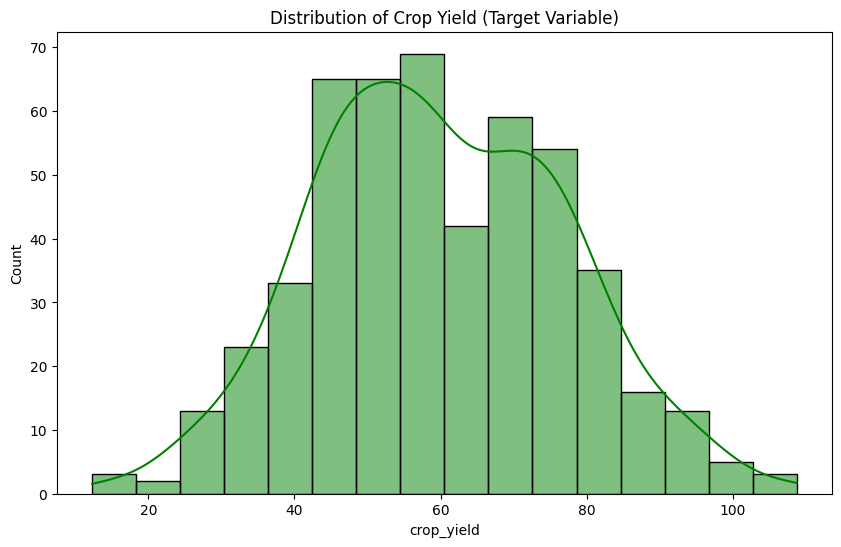

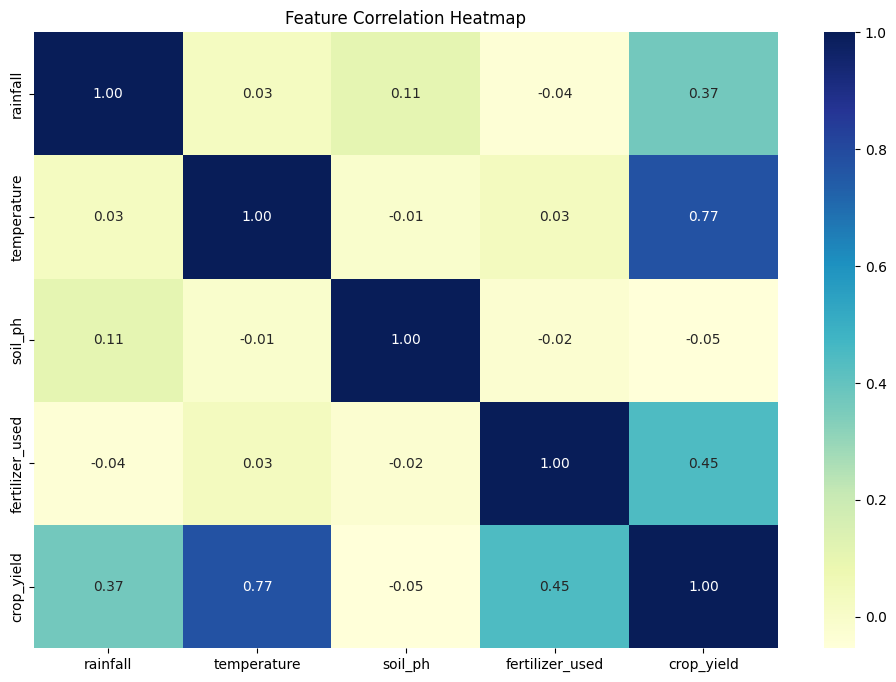


--- Model Performance Comparison ---
               Model  R2 Score        MAE       RMSE
0  Linear Regression  0.881709   4.556922   5.725826
3  Gradient Boosting  0.828260   5.442544   6.899192
2      Random Forest  0.814470   5.586076   7.170828
1      Decision Tree  0.695065   7.276213   9.193194
4                KNN  0.275720  11.820264  14.168238


/tmp/ipykernel_55/4096123278.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Model", data=df_results, palette="viridis")


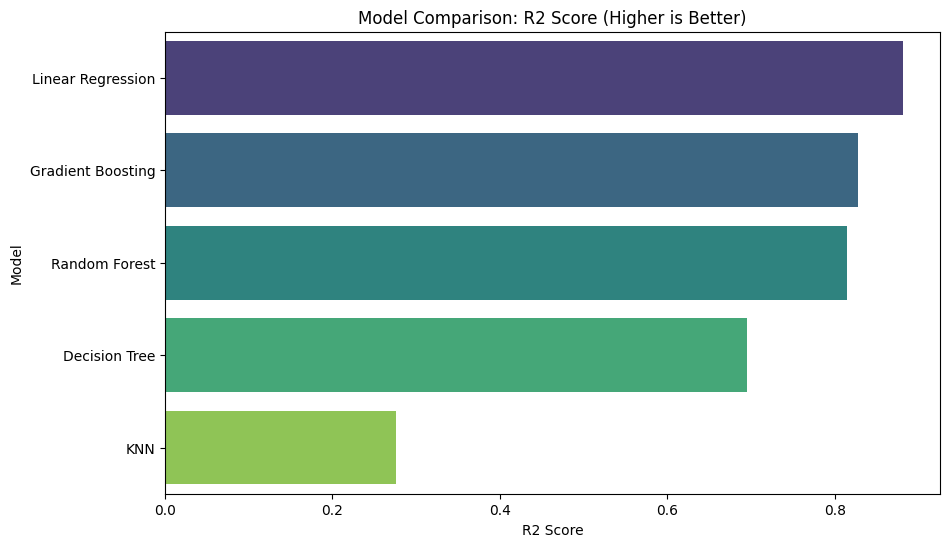

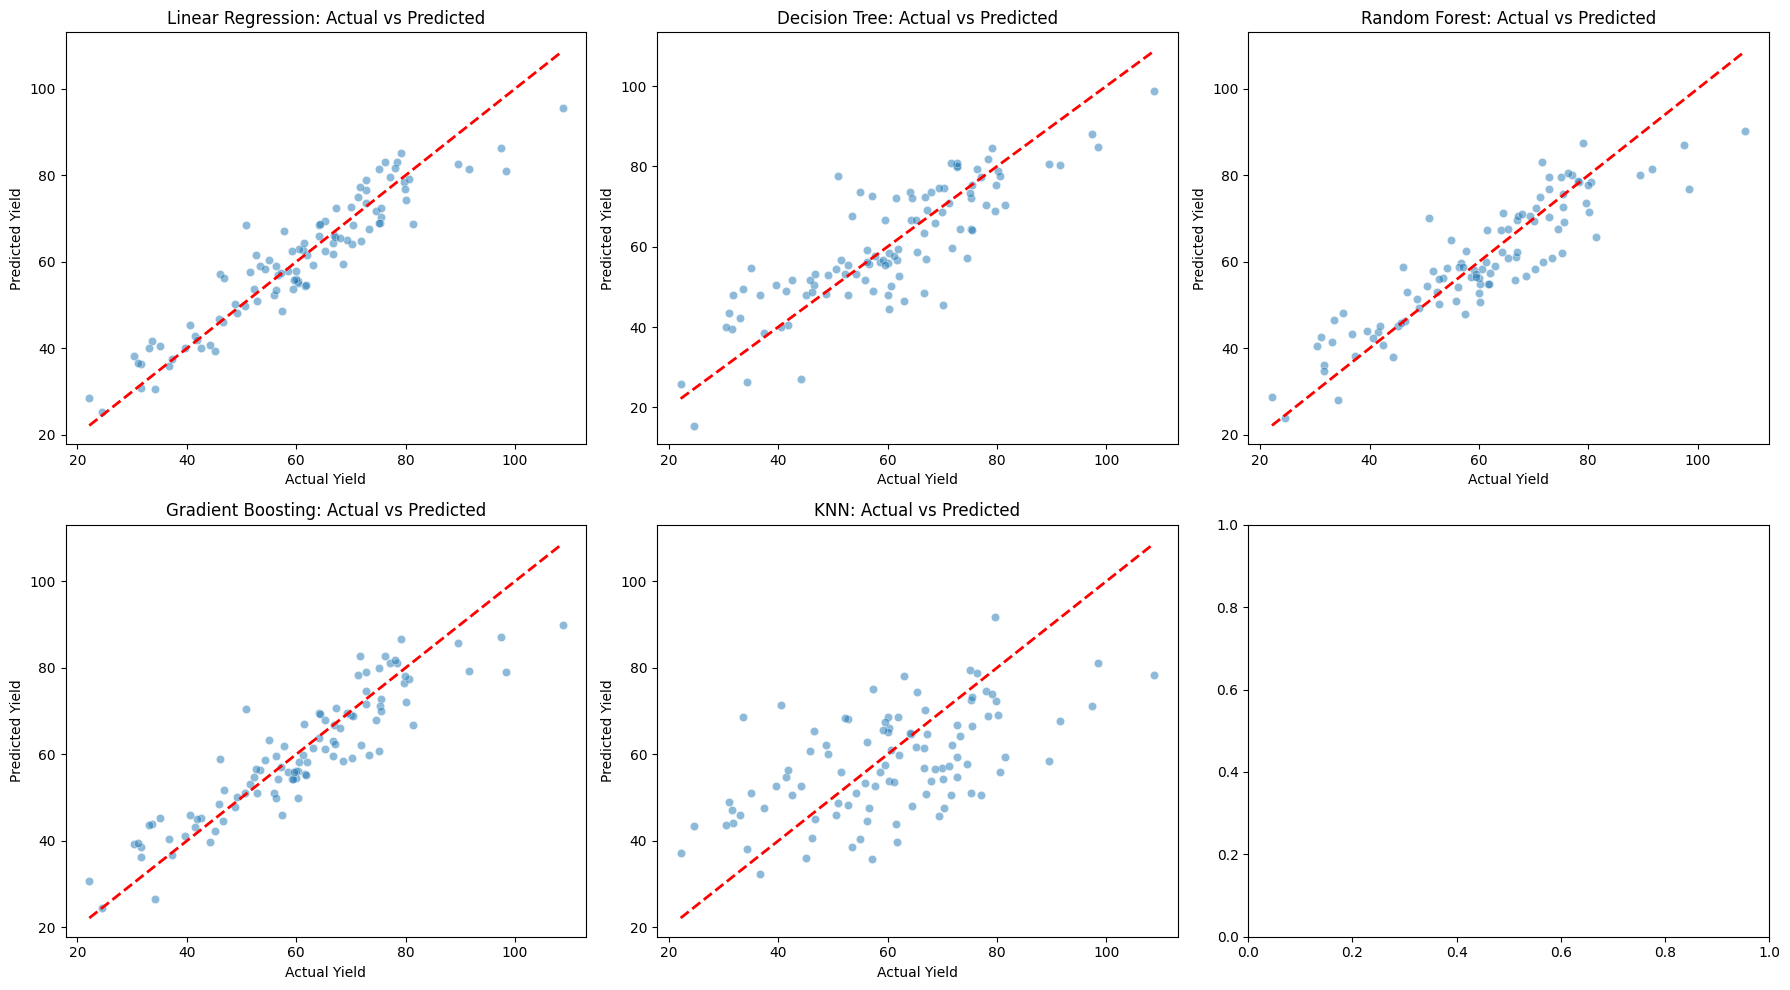

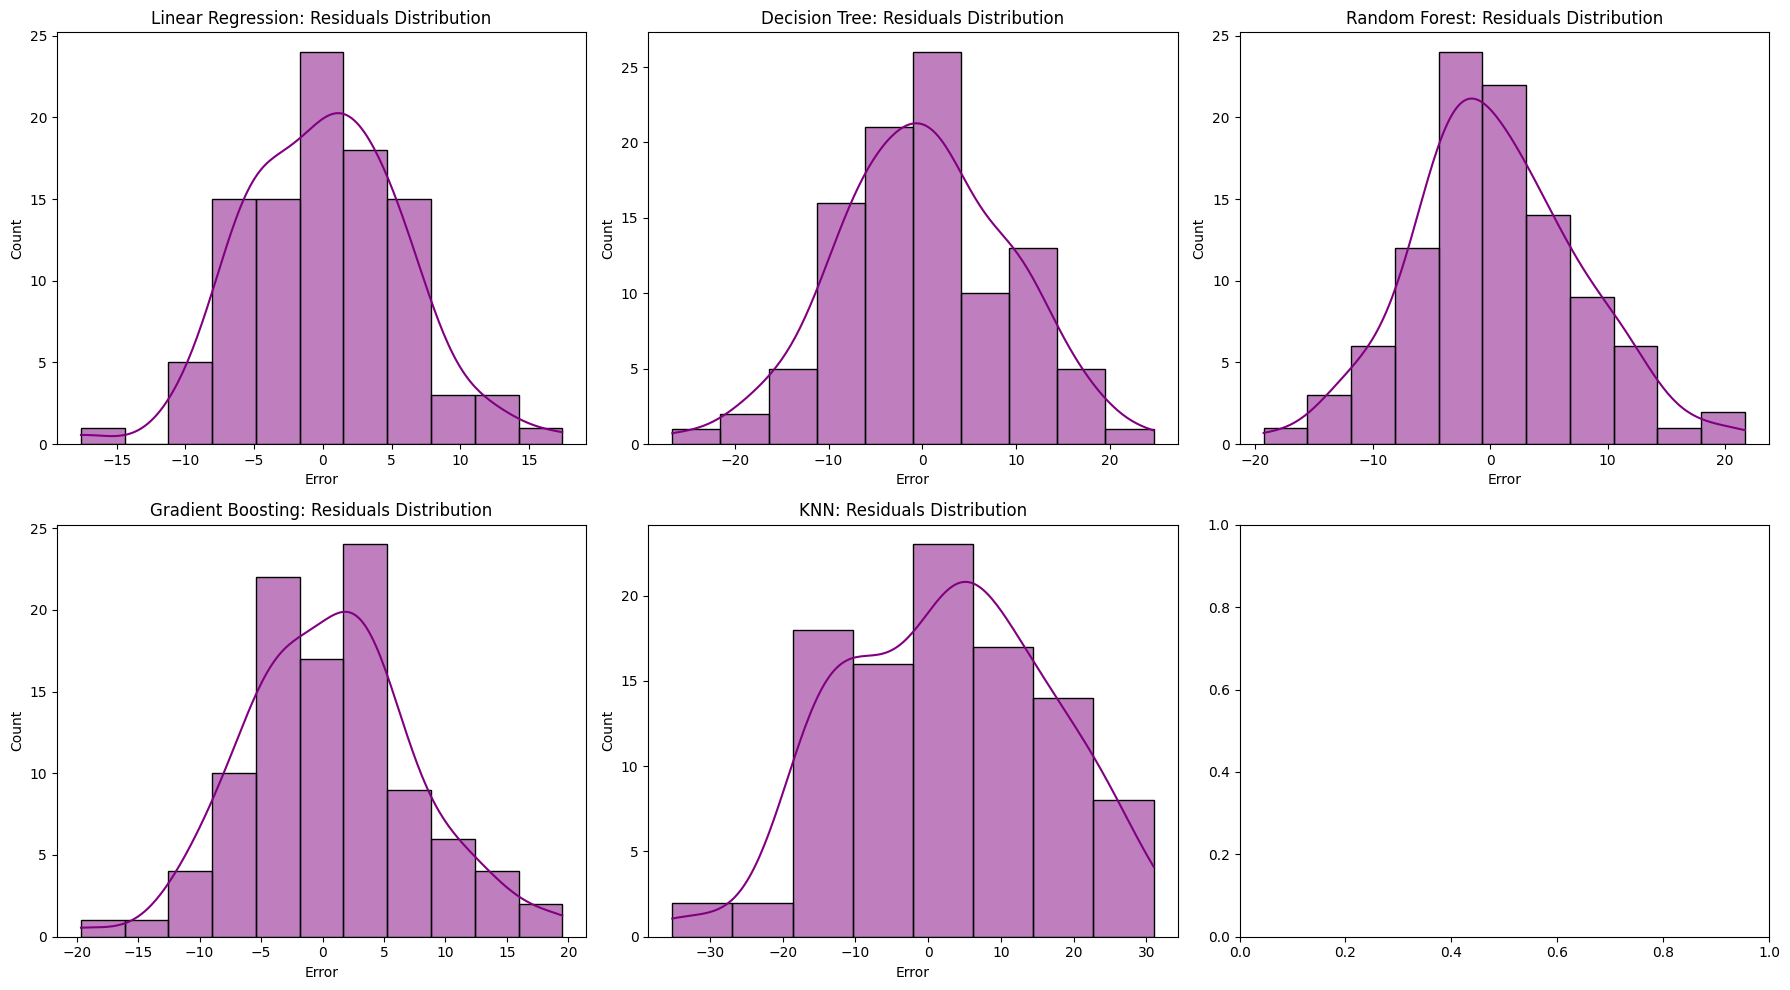

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# ==========================================
# 1. LOAD AND PREPROCESS DATA
# ==========================================
data = pd.read_csv("/kaggle/input/datasets/vigneshreddyk/crop-y/synthetic_crop_yield_data28129.csv")

# --- Data Preprocessing Visualizations ---
plt.figure(figsize=(10, 6))
sns.histplot(data['crop_yield'], kde=True, color='green')
plt.title('Distribution of Crop Yield (Target Variable)')
plt.show()

plt.figure(figsize=(12, 8))
# Only numeric columns for correlation
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Encoding categorical variables
data_encoded = pd.get_dummies(data, columns=["crop_type", "irrigation_type"], drop_first=True)

X = data_encoded.drop(columns=["crop_yield"])
y = data_encoded["crop_yield"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. MODEL TRAINING AND EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Calculate Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# --- Comparative Table ---
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\n--- Model Performance Comparison ---")
print(df_results)

# ==========================================
# 3. PERFORMANCE VISUALIZATIONS
# ==========================================

# A. Comparative Bar Chart (R2 Score)
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Model", data=df_results, palette="viridis")
plt.title("Model Comparison: R2 Score (Higher is Better)")
plt.show()

# B. Actual vs. Predicted Plots (The Regression equivalent of Confusion Matrix)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[i], alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[i].set_title(f'{name}: Actual vs Predicted')
    axes[i].set_xlabel('Actual Yield')
    axes[i].set_ylabel('Predicted Yield')

plt.tight_layout()
plt.show()

# C. Residual Plots (To check for prediction errors)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, ax=axes[i], color='purple')
    axes[i].set_title(f'{name}: Residuals Distribution')
    axes[i].set_xlabel('Error')

plt.tight_layout()
plt.show()